# Asset Class Trend Following 策略回測 (含停損機制與參數最佳化)
本筆記本實作了基於 SMA 與 ROC 的動能策略，並加入停損機制與份額保留邏輯。

## 1. 參數設定
在此區域設定策略的核心參數。

In [1]:
# 策略核心參數
SMA_LEN = 40        # 簡單移動平均線長度
ROC_LEN = 250       # 變動率計算期間
STOP_LOSS_TYPE = 'peak' # 停損類型: 'peak' (最高價回落) 或 'ma' (均線停損)
STOP_LOSS_VAL = 0.1 # 停損參數 (10% 或 MA天數)
RB_PERIOD = 5       # 再平衡週期 (交易日)
RB_OFFSET = 3       # 再平衡偏移量 (0-4)
INITIAL_CAPITAL = 30000000 # 初始資金
DATA_PATH = '0205/data.xlsx'


## 2. 導入套件與資料前處理

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import xlsxwriter

# 讀取並清理資料
def load_and_clean_data(path):
    df = pd.read_excel(path, header=[0, 1], index_col=0)
    df.index = pd.to_datetime(df.index)
    # 去除重複的 Ticker
    df = df.loc[:, ~df.columns.get_level_values(0).duplicated()]
    # 清理名稱
    new_cols = [(str(t).replace('.1', ''), str(n).replace('.1', '')) for t, n in df.columns]
    df.columns = pd.MultiIndex.from_tuples(new_cols, names=['Ticker', 'Name'])
    # 填補缺失值
    df = df.ffill().bfill()
    return df

df = load_and_clean_data(DATA_PATH)
print("資料讀取完成，形狀為:", df.shape)


資料讀取完成，形狀為: (1463, 120)


## 3. 回測引擎實作

In [3]:
import pandas as pd
import numpy as np

def run_backtest(df, sma_len, roc_len, stop_loss_type, stop_loss_val, rb_period=5, rb_offset=0, initial_capital=30_000_000):
    prices = df.copy()
    tickers = prices.columns.get_level_values(0)
    names = prices.columns.get_level_values(1)
    ticker_to_name = dict(zip(tickers, names))
    prices.columns = tickers
    
    sma = prices.rolling(sma_len).mean()
    roc = prices.pct_change(roc_len)
    
    dates = prices.index
    n_days = len(dates)
    
    cash = initial_capital
    holdings = {} # ticker -> {'shares': float, 'max_price': float, 'entry_date': date, 'entry_price': float}
    
    equity = pd.Series(index=dates, dtype=float)
    trade_log = []
    holdings_log = []
    
    pending_trades = [] 
    
    start_idx = max(sma_len, roc_len)
    if start_idx >= n_days:
        return pd.Series([initial_capital]*n_days, index=dates), [], []

    for i in range(start_idx, n_days):
        curr_date = dates[i]
        curr_prices = prices.iloc[i]
        
        # 1. Execute pending trades (at T+1 close)
        if pending_trades:
            # Execute sells first to get cash
            sells = [t for t in pending_trades if t['type'] == 'sell']
            buys = [t for t in pending_trades if t['type'] == 'buy']
            
            for trade in sells:
                ticker = trade['ticker']
                p = curr_prices[ticker]
                shares = trade['shares']
                cash += shares * p
                entry_info = holdings.pop(ticker, None)
                if entry_info:
                    trade_log.append({
                        'Date': curr_date,
                        'Ticker': ticker,
                        'Name': ticker_to_name[ticker],
                        'Type': 'Sell',
                        'Price': p,
                        'Shares': shares,
                        'Reason': trade['reason'],
                        'Entry Date': entry_info['entry_date'],
                        'Entry Price': entry_info['entry_price'],
                        'Return': (p / entry_info['entry_price']) - 1 if entry_info['entry_price'] != 0 else 0
                    })
            
            for trade in buys:
                ticker = trade['ticker']
                p = curr_prices[ticker]
                if p > 0:
                    amount = min(trade['amount'], cash)
                    if amount > 0:
                        shares = amount / p
                        holdings[ticker] = {
                            'shares': shares,
                            'max_price': p,
                            'entry_date': curr_date,
                            'entry_price': p
                        }
                        cash -= amount
                        trade_log.append({
                            'Date': curr_date,
                            'Ticker': ticker,
                            'Name': ticker_to_name[ticker],
                            'Type': 'Buy',
                            'Price': p,
                            'Shares': shares,
                        'Reason': trade['reason'],
                        'Momentum_Value': trade.get('momentum', 0)
                        })
            pending_trades = []

        # 2. Update Equity and Max Price
        port_value = cash
        for ticker, info in holdings.items():
            val = info['shares'] * curr_prices[ticker]
            port_value += val
            holdings[ticker]['max_price'] = max(holdings[ticker]['max_price'], curr_prices[ticker])
        equity.iloc[i] = port_value
        
        # 3. Log holdings
        holdings_log.append({
            'Date': curr_date,
            'Holdings': {t: info['shares'] for t, info in holdings.items()},
            'Equity': port_value
        })

        # 4. Signal Generation (for execution at T+1)
        if i == n_days - 1: continue
        
        # Stop Loss (Daily check)
        current_held_tickers = list(holdings.keys())
        for ticker in current_held_tickers:
            info = holdings[ticker]
            stop_triggered = False
            reason = ""
            if stop_loss_type == 'peak':
                if curr_prices[ticker] < info['max_price'] * (1 - stop_loss_val):
                    stop_triggered = True
                    reason = f"Peak-to-Trough Stop ({stop_loss_val*100}%)"
            elif stop_loss_type == 'ma':
                ma_stop_val = prices[ticker].rolling(int(stop_loss_val)).mean().iloc[i]
                if curr_prices[ticker] < ma_stop_val:
                    stop_triggered = True
                    reason = f"MA Stop ({stop_loss_val})"
            
            if stop_triggered:
                if not any(t['ticker'] == ticker and t['type'] == 'sell' for t in pending_trades):
                    pending_trades.append({'ticker': ticker, 'type': 'sell', 'shares': info['shares'], 'reason': reason})

        # Rebalance
        if (i - start_idx) % rb_period == rb_offset:
            eligible = (prices.iloc[i] > sma.iloc[i]) & (roc.iloc[i] > 0)
            eligible_roc = roc.iloc[i][eligible].sort_values(ascending=False)
            top_3 = eligible_roc.head(3).index.tolist()
            
            # Sell those not in top 3
            for ticker in list(holdings.keys()):
                if ticker not in top_3:
                    if not any(t['ticker'] == ticker and t['type'] == 'sell' for t in pending_trades):
                        pending_trades.append({'ticker': ticker, 'type': 'sell', 'shares': holdings[ticker]['shares'], 'reason': 'Dropped from Top 3'})
            
            # Buy new ones
            to_buy = [t for t in top_3 if t not in holdings and not any(tr['ticker'] == t and tr['type'] == 'buy' for tr in pending_trades)]
            if to_buy:
                # How many slots are open or will be open?
                filled_slots = len([t for t in top_3 if t in holdings and not any(tr['ticker'] == t and tr['type'] == 'sell' for tr in pending_trades)])
                open_slots = 3 - filled_slots
                if open_slots > 0:
                    amount_per_slot = port_value / 3
                    for ticker in to_buy[:open_slots]:
                        pending_trades.append({'ticker': ticker, 'type': 'buy', 'amount': amount_per_slot, 
                                               'reason': f'Top 3 ROC ({roc.iloc[i][ticker]:.4f})',
                                               'momentum': roc.iloc[i][ticker]})

    # Fill leading NaNs in equity
    equity = equity.ffill().fillna(initial_capital)
    return equity, trade_log, holdings_log

def calculate_metrics(equity):
    if equity.iloc[0] == 0: return {}
    total_return = (equity.iloc[-1] / equity.iloc[0]) - 1
    years = (equity.index[-1] - equity.index[0]).days / 365.25
    cagr = (1 + total_return) ** (1 / years) - 1 if years > 0 else 0
    
    drawdown = (equity / equity.cummax()) - 1
    max_dd = drawdown.min()
    
    calmar = cagr / abs(max_dd) if max_dd != 0 else 0
    
    daily_returns = equity.pct_change().dropna()
    win_rate = (daily_returns > 0).mean()
    
    return {
        'CAGR': cagr,
        'MaxDD': max_dd,
        'Calmar': calmar,
        'WinRate': win_rate,
        'TotalReturn': total_return
    }


## 4. 執行回測

In [4]:
equity, trades, h_log = run_backtest(df, SMA_LEN, ROC_LEN, STOP_LOSS_TYPE, STOP_LOSS_VAL, RB_PERIOD, RB_OFFSET, INITIAL_CAPITAL)
metrics = calculate_metrics(equity)
print("策略績效總結:")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")


策略績效總結:
CAGR: 1.3545
MaxDD: -0.2675
Calmar: 5.0644
WinRate: 0.4473
TotalReturn: 171.5893


## 5. 權益曲線視覺化

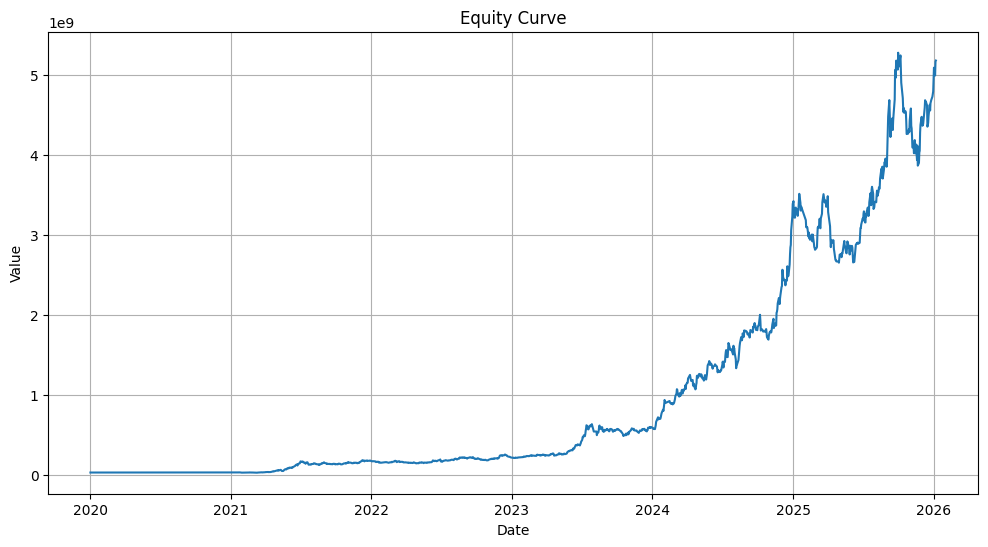

In [5]:
plt.figure(figsize=(12, 6))
plt.plot(equity, label='Strategy Equity')
plt.title('Equity Curve')
plt.xlabel('Date')
plt.ylabel('Value')
plt.grid(True)
plt.show()


## 6. 產出 Excel 報告

In [6]:
# 準備 Trades 工作表
trades_df = pd.DataFrame(trades)
# 加入最佳參數說明
trades_df['SMA_Param'] = SMA_LEN
trades_df['ROC_Param'] = ROC_LEN
trades_df['StopLoss_Param'] = f"{STOP_LOSS_TYPE}_{STOP_LOSS_VAL}"
# 加入繁體中文說明
def get_description(row):
    if row['Type'] == 'Buy':
        return f"選取動能值(ROC)為 {row['Momentum_Value']:.4f} 的資產 {row['Name']} 進場"
    else:
        return f"資產 {row['Name']} 因 {row['Reason']} 出場"
trades_df['說明'] = trades_df.apply(get_description, axis=1)

# 準備 Equity_Curve 工作表
equity_df = pd.DataFrame(equity, columns=['Equity'])
equity_df['Drawdown'] = (equity_df['Equity'] / equity_df['Equity'].cummax()) - 1
# 準備 Equity_Hold 工作表
h_rows = []
for entry in h_log:
    date = entry['Date']
    h = entry['Holdings']
    for t, s in h.items():
        h_rows.append({'Date': date, 'Ticker': t, 'Shares': s})
holdings_df = pd.DataFrame(h_rows)
# 準備 Summary 工作表
summary_df = pd.DataFrame([metrics])

with pd.ExcelWriter('strategy_results_equity.xlsx', engine='xlsxwriter') as writer:
    trades_df.to_excel(writer, sheet_name='Trades', index=False)
    equity_df.to_excel(writer, sheet_name='Equity_Curve')
    holdings_df.to_excel(writer, sheet_name='Equity_Hold', index=False)
    summary_df.to_excel(writer, sheet_name='Summary', index=False)
print("Excel 報告已產生: strategy_results_equity.xlsx")


Excel 報告已產生: strategy_results_equity.xlsx
